# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 0-4 숫자 중에서 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
# Subset(train_dataset, list1): 내가 원하는 인덱스를 가지는 데이터셋만 불러올 수 있음
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다), 한 번 데이터를 가져올 때 64개씩 가져오도록 설정
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True) # 매 epochs마다 데이터를 섞는 모습을 볼 수 있습니다.
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [2]:
for i, (data, target) in enumerate(train_loader):
        print(i, data.shape, target.shape, target)

0 torch.Size([64, 1, 28, 28]) torch.Size([64]) tensor([0, 4, 4, 4, 0, 3, 2, 3, 1, 1, 4, 2, 0, 2, 2, 0, 3, 4, 0, 1, 2, 2, 4, 2,
        3, 3, 3, 0, 2, 3, 3, 3, 2, 3, 2, 0, 0, 3, 1, 4, 3, 2, 2, 2, 2, 0, 4, 2,
        0, 4, 3, 3, 2, 1, 1, 2, 3, 2, 0, 3, 1, 2, 0, 2])
1 torch.Size([64, 1, 28, 28]) torch.Size([64]) tensor([3, 4, 1, 3, 2, 1, 4, 1, 0, 4, 0, 2, 4, 1, 2, 1, 0, 1, 0, 1, 1, 0, 1, 2,
        4, 4, 4, 0, 2, 1, 1, 3, 1, 0, 1, 4, 0, 3, 0, 2, 1, 3, 1, 0, 0, 1, 1, 0,
        3, 1, 3, 0, 3, 3, 0, 4, 1, 3, 1, 4, 1, 1, 3, 2])
2 torch.Size([64, 1, 28, 28]) torch.Size([64]) tensor([1, 3, 4, 3, 2, 0, 3, 4, 0, 1, 3, 4, 1, 4, 3, 2, 3, 1, 3, 3, 3, 1, 0, 1,
        1, 1, 0, 1, 4, 4, 1, 1, 3, 2, 4, 0, 4, 2, 0, 2, 2, 3, 1, 0, 0, 1, 0, 2,
        1, 2, 2, 2, 2, 1, 3, 0, 0, 2, 4, 4, 3, 4, 1, 1])
3 torch.Size([64, 1, 28, 28]) torch.Size([64]) tensor([1, 2, 4, 4, 2, 0, 0, 2, 3, 1, 0, 4, 1, 3, 1, 2, 2, 2, 0, 0, 2, 4, 1, 3,
        1, 4, 1, 1, 2, 0, 2, 0, 4, 1, 3, 3, 4, 2, 3, 0, 2, 3, 4, 2, 0, 2, 4, 1,
 

In [3]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


torch.Size([1, 28, 28])
(28, 28)


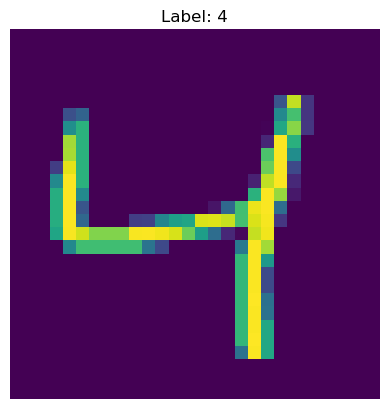

In [4]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
# image는 이미지 데이터 정보, label은 데이터가 어떤 레이블(숫자)를 가지는지
image, label = train_subset[1]

print(image.shape) # (1, 28, 28)

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze() # 텐서의 차원을 줄여서 시각화하기 쉽게 만들기 위해서 (1인 차원을 자동으로 제거)

print(image.shape) # (28, 28)

# 이미지 출력
plt.imshow(image)  # 이미지 표시, (H, W) 형식의 배열
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden layer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [5]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [6]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

#### **ANN 모델 학습**

In [7]:
# ANN 객체 생성
input_dim = 28 * 28 # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [8]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        # 정확도 측정
        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.21078874170780182  Accuracy: 96.3222427368164 %
Iteration: 1000  Loss: 0.1332366019487381  Accuracy: 97.15898132324219 %
Iteration: 1500  Loss: 0.041934240609407425  Accuracy: 97.47032165527344 %
Iteration: 2000  Loss: 0.0860045999288559  Accuracy: 97.76220703125 %
Iteration: 2500  Loss: 0.20480597019195557  Accuracy: 97.87896728515625 %
Iteration: 3000  Loss: 0.02430303953588009  Accuracy: 97.95680236816406 %
Iteration: 3500  Loss: 0.055869195610284805  Accuracy: 98.17085266113281 %
Iteration: 4000  Loss: 0.04705957695841789  Accuracy: 98.26814270019531 %
Iteration: 4500  Loss: 0.09100425243377686  Accuracy: 98.34598541259766 %


#### **ANN 학습 결과**

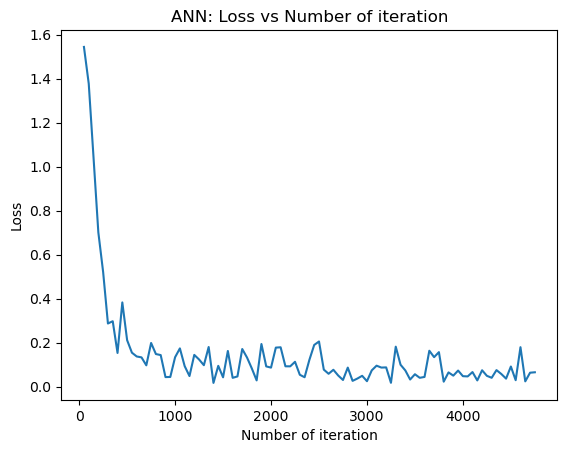

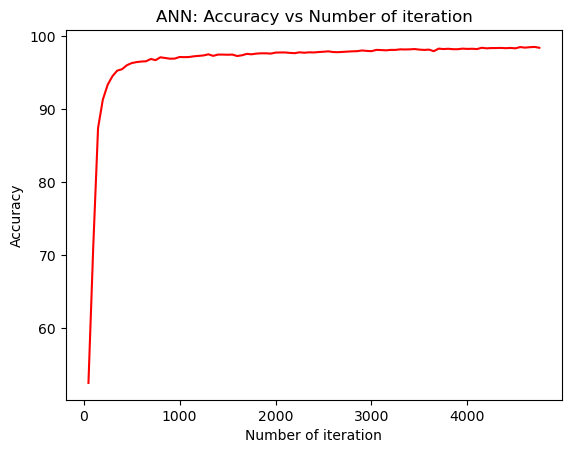

In [9]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**

Iteration 횟수가 커질 수록 Loss는 급격하게 감소하고, 정확도는 올라간다. 초기 손실은 약 1.6에서 시작하지만, 빠르게 감소하고, 400~500회 반복 이후부터는 손실이 0에 가까운 값으로 진동하면서 유지되고 있음. 초기 정확도는 약 60% 정도에서 시작하고, 반복 횟수가 증가하면서 급격히 상승한다. 약 700회 반복 이후에는 95 % 사이를 도달하고, 이후 천천히 증가하면서 거의 99%에 가가운 정확도를 달성한다. 

#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [10]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
input_dim = 28 * 28 # 이미지 크기 (28x28)
hidden_dims = [50, 100, 150, 200]
output_dim = 5  # 출력 클래스 개수 (0~4)

loss_ftn = nn.CrossEntropyLoss()  # 손실 함수 정의

loss_list = [[], [], [], []]  # 각 hidden_dim별 loss 저장
accuracy_list = [[], [], [], []]  # 정확도도 따로 저장하고 싶다면
iteration_list = [[], [], [], []]  # Iteration 저장 리스트

for idx, h in enumerate(hidden_dims):
    # ANN 모델 학습
    model = ANNModel(input_dim, h, output_dim)

    # 학습을 모니터링하기 위한 변수들
    count = 0  # 반복 횟수

    # Optimizer 초기화
    learning_rate = 0.02
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    # 전체 학습
    for epoch in range(10):

        # 배치 단위 학습
        for i, (images, labels) in enumerate(train_loader):

            # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
            train = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
            labels = labels  # 텐서 형태 유지

            optimizer.zero_grad()

            # Forward
            # 모델을 이용해 예측값(outputs) 계산
            outputs = model(train)

            # 손실 계산
            # cross entropy loss를 사용해 예측값과 실제값 비교
            loss = loss_ftn(outputs, labels)

            # Backward propagation - 손실에 대한 기울기 계산
            loss.backward()

            # 가중치 업데이트
            optimizer.step()

            count += 1  # 반복 횟수 증가

            # 정확도 측정
            if count % 50 == 0:
                # 정확도 계산을 위한 변수 초기화
                correct = 0
                total = 0


                # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
                for images, labels in test_loader:

                    test = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                    # Forward
                    # 예측값 계산
                    outputs = model(test)

                    # 예측값 중 가장 높은 값을 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 개수
                    total += len(labels)

                    # 올바르게 예측한 개수
                    correct += (predicted == labels).sum()

                # 정확도 계산
                accuracy = 100 * correct / float(total)

                # 손실 및 정확도 저장
                loss_list[idx].append(loss.item())
                accuracy_list[idx].append(accuracy)
                iteration_list[idx].append(count)

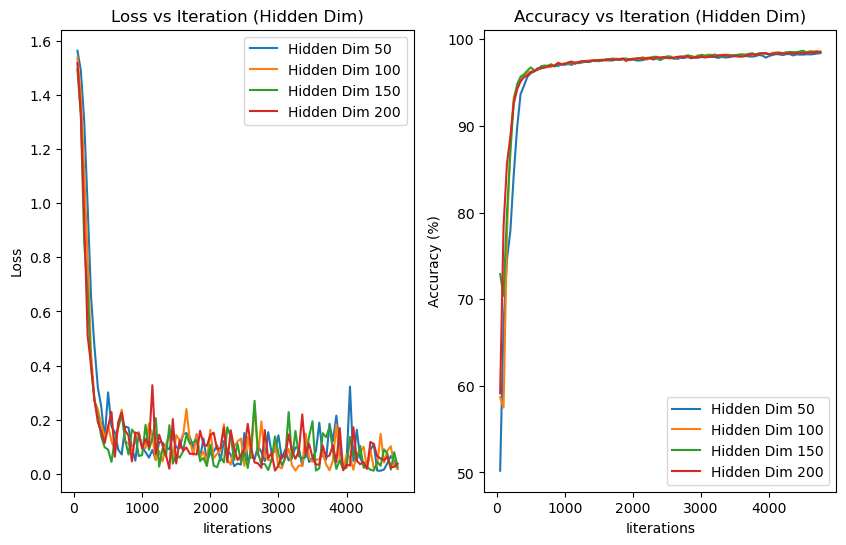

In [11]:
# 실험 1 모델 학습 결과 시각화
fig = plt.figure(figsize=(10, 6)) 

plt.subplot(1, 2, 1)
for i, h in enumerate(hidden_dims):   
    plt.plot(iteration_list[i], loss_list[i], label=f'Hidden Dim {h}')             
plt.xlabel("Iiterations")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Iteration (Hidden Dim)")

plt.subplot(1, 2, 2)
for i, h in enumerate(hidden_dims):    
    plt.plot(iteration_list[i], accuracy_list[i], label=f'Hidden Dim {h}')
plt.xlabel("Iiterations")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy vs Iteration (Hidden Dim)")
plt.show()


**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- 
- Hidden Dim이 클 수록 Loss의 진동폭이 더 작고 안정적으로 수렴한다
- Hidden Dim이 클 수록 같은 반복 횟수에서 Accuracy가 더 높고, 빠르게 올라간다. 

In [13]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습

input_dim = 28 * 28 # 이미지 크기 (28x28)
hidden_dim = 150
output_dim = 5  # 출력 클래스 개수 (0~4)

learning_rates = [0.005, 0.01, 0.05, 0.1]

loss_ftn = nn.CrossEntropyLoss()  # 손실 함수 정의

loss_list = [[], [], [], []]  # 각 hidden_dim별 loss 저장
accuracy_list = [[], [], [], []]  # 정확도도 따로 저장하고 싶다면
iteration_list = [[], [], [], []]  # Iteration 저장 리스트

for idx, lr in enumerate(learning_rates):
    # ANN 모델 학습
    model = ANNModel(input_dim, hidden_dim, output_dim)

    # 학습을 모니터링하기 위한 변수들
    count = 0  # 반복 횟수

    # Optimizer 초기화
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # 전체 학습
    for epoch in range(10):

        # 배치 단위 학습
        for i, (images, labels) in enumerate(train_loader):

            # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
            train = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
            labels = labels  # 텐서 형태 유지

            optimizer.zero_grad()

            # Forward
            # 모델을 이용해 예측값(outputs) 계산
            outputs = model(train)

            # 손실 계산
            # cross entropy loss를 사용해 예측값과 실제값 비교
            loss = loss_ftn(outputs, labels)

            # Backward propagation - 손실에 대한 기울기 계산
            loss.backward()

            # 가중치 업데이트
            optimizer.step()

            count += 1  # 반복 횟수 증가

            # 정확도 측정
            if count % 50 == 0:
                # 정확도 계산을 위한 변수 초기화
                correct = 0
                total = 0


                # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
                for images, labels in test_loader:

                    test = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                    # Forward
                    # 예측값 계산
                    outputs = model(test)

                    # 예측값 중 가장 높은 값을 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 개수
                    total += len(labels)

                    # 올바르게 예측한 개수
                    correct += (predicted == labels).sum()

                # 정확도 계산
                accuracy = 100 * correct / float(total)

                # 손실 및 정확도 저장
                loss_list[idx].append(loss.item())
                accuracy_list[idx].append(accuracy)
                iteration_list[idx].append(count)

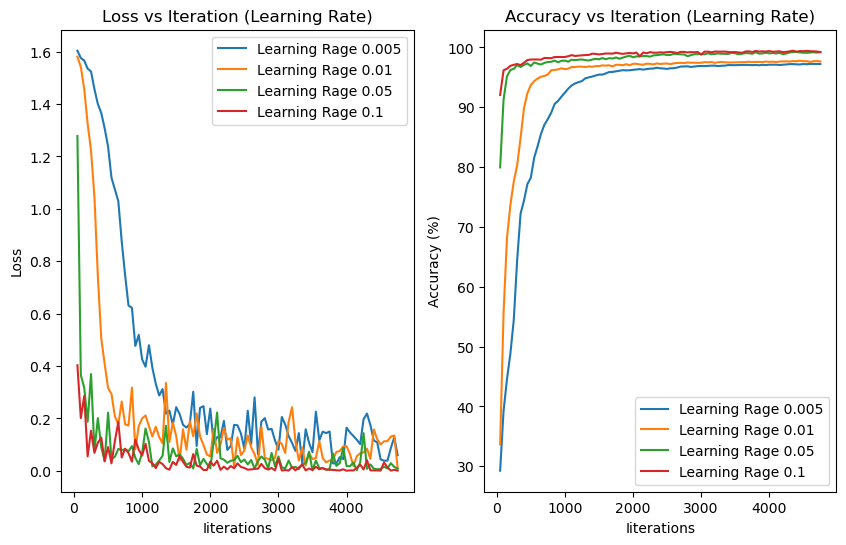

In [14]:
# 실험 2 모델 학습 결과 시각화
fig = plt.figure(figsize=(10, 6)) 

plt.subplot(1, 2, 1)
for i, lr in enumerate(learning_rates):   
    plt.plot(iteration_list[i], loss_list[i], label=f'Learning Rage {lr}')             
plt.xlabel("Iiterations")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Iteration (Learning Rate)")

plt.subplot(1, 2, 2)
for i, lr in enumerate(learning_rates):    
    plt.plot(iteration_list[i], accuracy_list[i], label=f'Learning Rage {lr}')
plt.xlabel("Iiterations")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy vs Iteration (Learning Rate)")
plt.show()


**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
-
- 학습률이 작으면 loss가 느리게 수렴하지만 안정적인 모습을 보여준다. 학습률이 클 때는 매우 빠르게 초기 손실이 감소하고, 거의 0 근처에서 빠르게 수렴한다. 
- 학습률이 작으면 accuracy 역시 느리게 수렴하고, 학습률이 빠른 모델들보다 정확도가 낮다. 학습률이 높을 때는 정확도가 매우 빠르게 높은 값으로 수렴한다. 
- 전체적으로 학습속도가 빠른 모델이 손실 함수와 정확도 모두에서 우수한 양상을 보인다. 

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU() # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(512, 10)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [16]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [17]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.517635188744032
Epoch 2, Loss: 0.12359581503527149
Epoch 3, Loss: 0.1054431775794802
Epoch 4, Loss: 0.08576213895870151
Epoch 5, Loss: 0.07589019433884941
Epoch 6, Loss: 0.0679763797748375
Epoch 7, Loss: 0.06075946083593733
Epoch 8, Loss: 0.05609198581886192
Epoch 9, Loss: 0.05200253882773983
Epoch 10, Loss: 0.04916258833890232
Epoch 11, Loss: 0.04402132175613918
Epoch 12, Loss: 0.041337268022294905
Epoch 13, Loss: 0.039066384855603375
Epoch 14, Loss: 0.03662563584811036
Epoch 15, Loss: 0.03498534315801857
Epoch 16, Loss: 0.033268900126868194
Epoch 17, Loss: 0.031771414897621884
Epoch 18, Loss: 0.030568469205184884
Epoch 19, Loss: 0.029235659628214086
Epoch 20, Loss: 0.02819997741036809


#### **CNN 학습 결과**

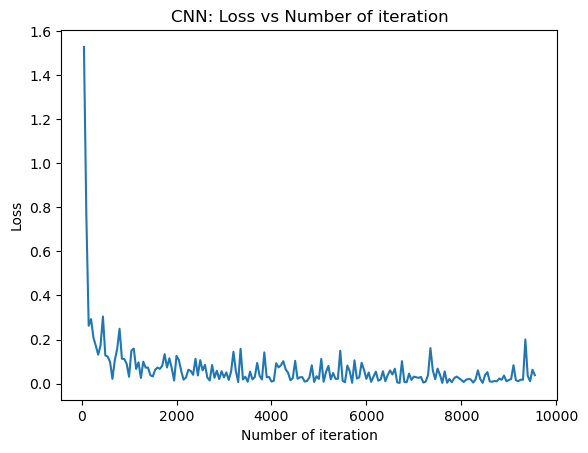

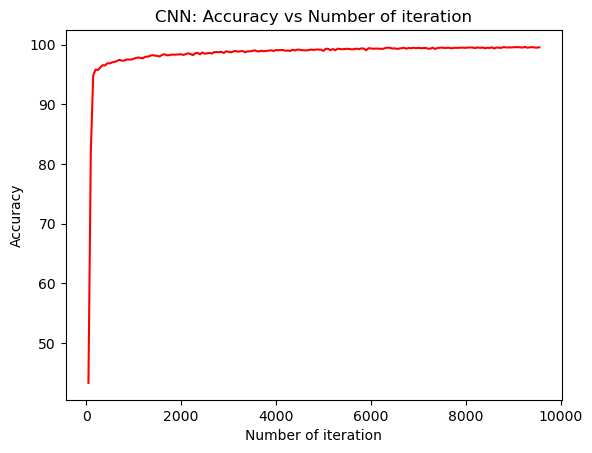

In [18]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
-
- CNN 모델은 초기 손실이 매우 빠르게 감소하였고, 손실의 진동폭도 ANN보다 작다. 정확도 또한 초기에 95% 가까이 증가하였고, 최종 정확도도 매우 높은 수준을 안정적으로 유지했다. 
- 학습 속도와 손실 안정성과 정확도를 모두 고려했을 때 CNN이 ANN보다 뛰어난 성과를 보였다. 즉, 이미지 데이터 MNIST에는 CNN을 사용하는 것이 더 적합해보인다. 
- ANN은 입력층, 은닉층, 출력층의 구조를 가지는 전통적인 인공 신경망으로, 이미지를 평탄화해서 사용하기 때문에 이미지의 공간 구조는 고려하지 못한다. 
- CNN은 합성곱 계층과 활성화 함수, Pooling 계층, 완전 연결층을 사용하는 합성곱 신경망이다. 공간 정보를 보존하면서 특징을 추출하기 때문에 이미지 데이터를 처리할 때 유용하다. 
